# 04 - Clustering
### Discovering hidden attack behavior patterns

Attack **labels are never used during training** in this notebook -- only
network flow features. Labels are brought back in at the very end, purely
to interpret what each discovered cluster corresponds to in the real
world (e.g. "cluster 3 turned out to be mostly PortScan traffic").


## 1. Imports

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

sys.path.insert(0, os.path.join("..", "src"))
import preprocessing as prep
import utils

utils.set_plot_style()
RANDOM_STATE = 42
PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models", "clustering")
FIGURES_DIR = os.path.join("..", "reports", "figures")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


## 2. Load data and take a clustering-appropriate sample

Clustering algorithms have their own scaling limits, separate from the
classification/regression notebooks:

- **K-Means** handles tens of thousands of rows comfortably.
- **Agglomerative clustering** builds a full pairwise distance matrix --
  memory grows with the *square* of the row count, so it needs a much
  smaller sample (a few thousand rows) or it can exhaust memory entirely.
- **t-SNE** is also expensive at scale and is run on the same small
  sample as Agglomerative.

The label column is kept alongside for now (dropped before any model
actually sees the data) so it's available for the interpretation step
at the end.

In [2]:
clean_path = os.path.join(PROCESSED_DIR, "cleaned_dataset.csv")
if not os.path.exists(clean_path):
    raise FileNotFoundError(
        "data/processed/cleaned_dataset.csv not found. Run 01_EDA.ipynb first."
    )

df = pd.read_csv(clean_path, low_memory=False)
label_col = "label" if "label" in df.columns else df.columns[-1]

KMEANS_SAMPLE_SIZE = 40_000
HIERARCHICAL_SAMPLE_SIZE = 5_000  # Agglomerative + t-SNE both use this smaller sample

kmeans_df = prep.stratified_sample(df, label_col=label_col, max_total=KMEANS_SAMPLE_SIZE, min_per_class=100)
hier_df = prep.stratified_sample(kmeans_df, label_col=label_col, max_total=HIERARCHICAL_SAMPLE_SIZE, min_per_class=20)

print(f"K-Means sample: {kmeans_df.shape[0]:,} rows")
print(f"Hierarchical/t-SNE sample: {hier_df.shape[0]:,} rows (subset of the K-Means sample)")


K-Means sample: 28,132 rows
Hierarchical/t-SNE sample: 4,064 rows (subset of the K-Means sample)


## 3. Feature preparation, correlation filtering, and scaling

Labels are set aside here (`true_labels_*`) and not passed to any model
below -- only used in section 9 for interpretation.

In [3]:
def prepare_features(sample_df):
    true_labels = sample_df[label_col].reset_index(drop=True)
    X = sample_df.drop(columns=[label_col]).reset_index(drop=True)
    return X, true_labels

X_kmeans_raw, true_labels_kmeans = prepare_features(kmeans_df)
X_hier_raw, true_labels_hier = prepare_features(hier_df)


In [4]:
# Correlation filtering: with ~78 features, drop one feature from every
# highly-correlated pair so redundant features don't silently double-count
# in the Euclidean distances K-Means and Agglomerative both rely on.
CORR_THRESHOLD = 0.9
corr = X_kmeans_raw.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

print(f"Dropping {len(to_drop)} correlated features (|r| > {CORR_THRESHOLD}): {to_drop}")
X_kmeans_pruned = X_kmeans_raw.drop(columns=to_drop)
X_hier_pruned = X_hier_raw.drop(columns=to_drop)


Dropping 33 correlated features (|r| > 0.9): ['total_backward_packets', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_iat_max', 'fwd_iat_total', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_max', 'fwd_header_length', 'bwd_header_length', 'fwd_packetss', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'syn_flag_count', 'ece_flag_count', 'average_packet_size', 'avg_fwd_segment_size', 'avg_bwd_segment_size', 'fwd_header_length1', 'subflow_fwd_packets', 'subflow_fwd_bytes', 'subflow_bwd_packets', 'subflow_bwd_bytes', 'act_data_pkt_fwd', 'active_max', 'active_min', 'idle_mean', 'idle_max', 'idle_min']


In [5]:
# Scale AFTER pruning. hier_df is a SUBSET of kmeans_df (see section 2), so
# the scaler is fit once on the larger K-Means sample and reused to transform
# the smaller hierarchical sample -- fitting a second, separate scaler on the
# smaller sample would put the two samples on slightly different scales and
# make the PCA step below inconsistent between them.
scaler_clustering = StandardScaler()
X_kmeans_scaled = scaler_clustering.fit_transform(X_kmeans_pruned)
X_hier_scaled = scaler_clustering.transform(X_hier_pruned)

print(f"K-Means feature matrix: {X_kmeans_scaled.shape}")
print(f"Hierarchical feature matrix: {X_hier_scaled.shape}")


K-Means feature matrix: (28132, 46)
Hierarchical feature matrix: (4064, 46)


## 4. Dimensionality reduction with PCA (for clustering, not just visualization)

With dozens of features, Euclidean distance -- which both K-Means and
Agglomerative rely on -- becomes less meaningful (the "curse of
dimensionality": in high dimensions, distances between points tend to
converge). PCA reduces to the smallest number of components that still
explain most of the variance, which clustering is then performed on. A
*separate* 2-component PCA is used purely for the visualizations later.

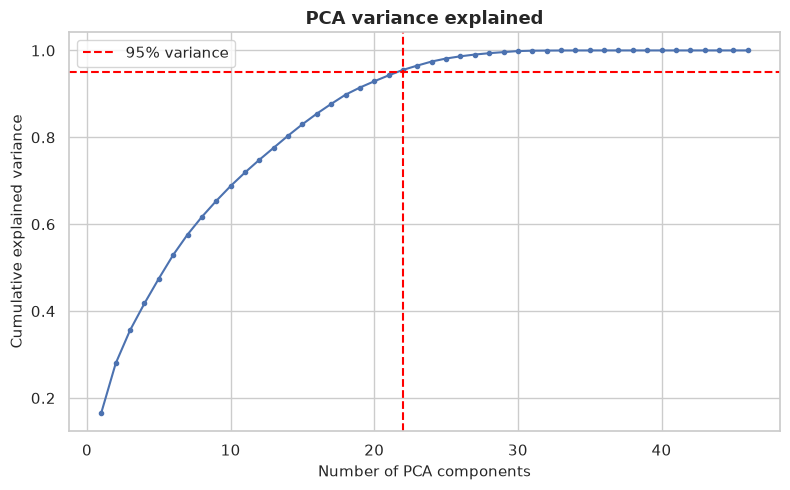

22 components explain 95% of the variance -- clustering uses this reduced space.


In [6]:
pca_variance = PCA(random_state=RANDOM_STATE).fit(X_kmeans_scaled)
cumulative_variance = np.cumsum(pca_variance.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker=".")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axvline(n_components_95, color="red", linestyle="--")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA variance explained")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_variance_explained.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"{n_components_95} components explain 95% of the variance -- clustering uses this reduced space.")


In [7]:
pca_model = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_kmeans_reduced = pca_model.fit_transform(X_kmeans_scaled)
# Same fitted PCA reused on the hierarchical sample -- consistent with reusing
# the same scaler above, since hier_df is a subset of the same population.
X_hier_reduced = pca_model.transform(X_hier_scaled)
print(f"Reduced K-Means matrix: {X_kmeans_reduced.shape}, reduced hierarchical matrix: {X_hier_reduced.shape}")


Reduced K-Means matrix: (28132, 22), reduced hierarchical matrix: (4064, 22)


## 5. K-Means: elbow curve and optimal k

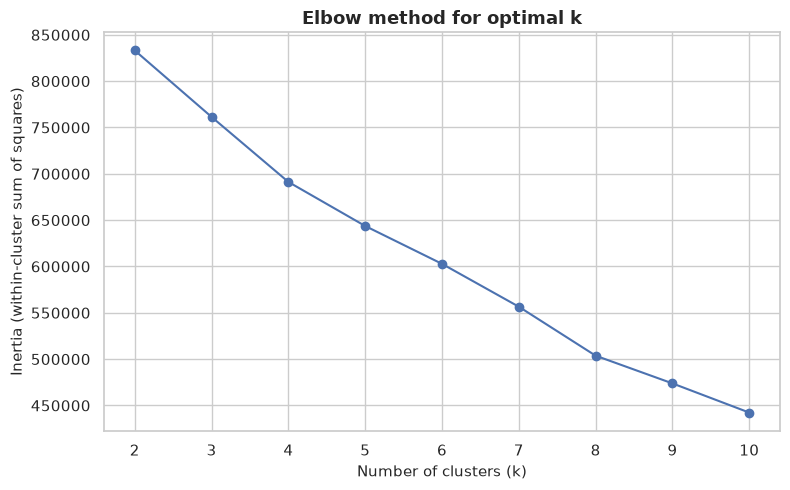

In [8]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X_kmeans_reduced)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_kmeans_reduced, km_labels, sample_size=5000, random_state=RANDOM_STATE))

utils.plot_elbow_curve(k_range, inertias, save_path=os.path.join(FIGURES_DIR, "kmeans_elbow.png"))


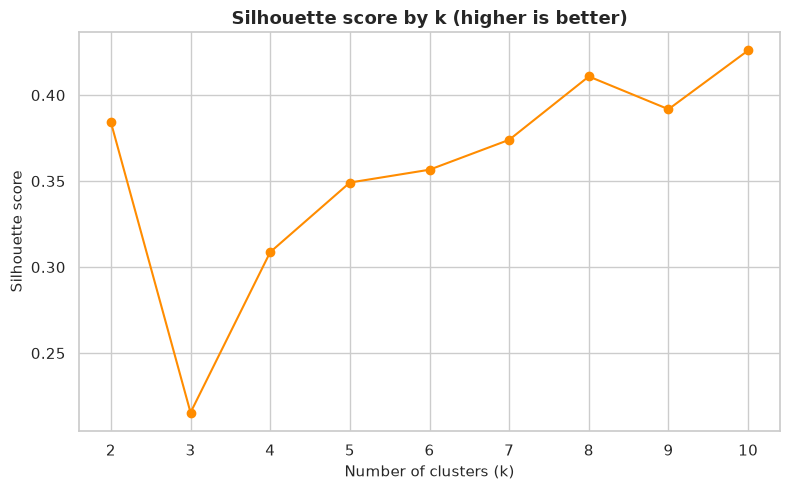

k with the best silhouette score: 10


In [9]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouettes, marker="o", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by k (higher is better)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "kmeans_silhouette_by_k.png"), dpi=150, bbox_inches="tight")
plt.show()

OPTIMAL_K = list(k_range)[int(np.argmax(silhouettes))]
print(f"k with the best silhouette score: {OPTIMAL_K}")


In [10]:
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_kmeans_reduced)
print(f"K-Means fit with k={OPTIMAL_K}")
print(pd.Series(kmeans_labels).value_counts().sort_index())


K-Means fit with k=10
0     2067
1    15240
2     1037
3     6073
4      526
5     1421
6       11
7     1395
8        5
9      357
Name: count, dtype: int64


## 6. Agglomerative hierarchical clustering

Run on the smaller `hier_df` sample only (see section 2 for why).

**A note before the linkage comparison below:** silhouette score alone can
be misleading for hierarchical clustering. "Average" and "single" linkage
in particular can produce a degenerate split -- almost every point crammed
into one giant cluster with a handful of outlier singletons -- which often
scores *higher* on silhouette than a genuinely useful, balanced
segmentation would. The comparison below checks cluster balance alongside
the score for exactly this reason.

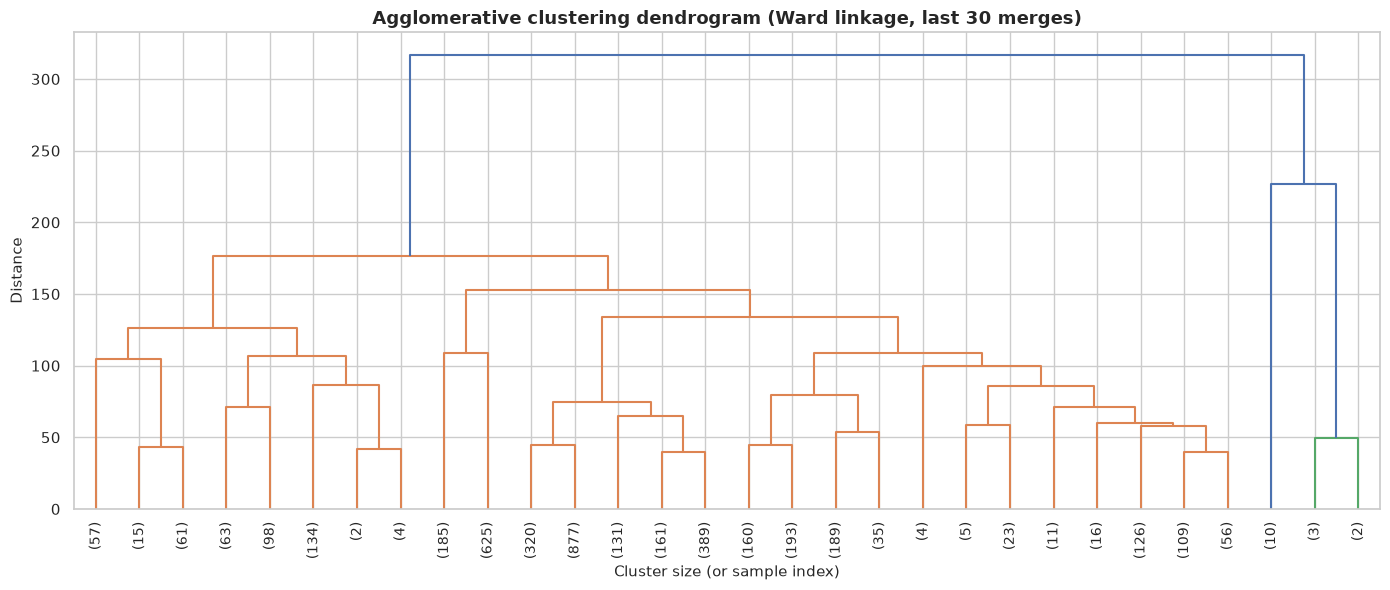

In [11]:
# Dendrogram -- shows the full merge hierarchy, using Ward linkage (minimizes
# within-cluster variance at each merge, generally a strong default).
Z = linkage(X_hier_reduced, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Agglomerative clustering dendrogram (Ward linkage, last 30 merges)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "dendrogram.png"), dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# Linkage comparison: try a few linkage methods at the same k chosen for
# K-Means. "average" and "single" linkage are known to sometimes produce a
# degenerate split -- nearly every point in one giant cluster plus a few
# outlier singletons -- which can score deceptively HIGH on silhouette
# despite being a useless segmentation. So alongside the score, we also
# check how balanced each method's clusters actually are, and only accept
# a non-ward result if it is both better-scoring AND reasonably balanced.
linkage_methods = ["ward", "complete", "average"]
linkage_scores = {}
linkage_balance = {}  # fraction of points in the single largest cluster

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=method)
    agg_labels = agg.fit_predict(X_hier_reduced)
    score = silhouette_score(X_hier_reduced, agg_labels)
    largest_cluster_fraction = pd.Series(agg_labels).value_counts(normalize=True).max()
    linkage_scores[method] = score
    linkage_balance[method] = largest_cluster_fraction
    print(f"linkage={method}: silhouette={score:.4f}, largest cluster = "
          f"{largest_cluster_fraction * 100:.1f}% of points")

DEGENERATE_THRESHOLD = 0.90  # one cluster holding >90% of points is a red flag
candidates = {m: s for m, s in linkage_scores.items() if linkage_balance[m] <= DEGENERATE_THRESHOLD}

if candidates:
    best_linkage = max(candidates, key=candidates.get)
else:
    # every method degenerated -- fall back to ward, the more robust default
    best_linkage = "ward"

print(f"\nBest linkage method: {best_linkage}"
      + (" (fell back to ward -- every method produced a >90% dominant cluster)" if not candidates else ""))


linkage=ward: silhouette=0.4534, largest cluster = 46.2% of points


linkage=complete: silhouette=0.4228, largest cluster = 98.2% of points


linkage=average: silhouette=0.6949, largest cluster = 99.1% of points

Best linkage method: ward


In [13]:
agglomerative_final = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage=best_linkage)
agglomerative_labels = agglomerative_final.fit_predict(X_hier_reduced)
print(pd.Series(agglomerative_labels).value_counts().sort_index())


0     133
1     350
2     140
3     577
4     161
5      10
6    1878
7       5
8     185
9     625
Name: count, dtype: int64


## 7. Evaluation metrics

- **Silhouette score** (-1 to 1, higher better): how well-separated
  clusters are.
- **Davies-Bouldin index** (0+, lower better): average similarity between
  each cluster and its most similar neighbor.
- **Calinski-Harabasz index** (0+, higher better): ratio of between- to
  within-cluster dispersion.

In [14]:
metrics_table = pd.DataFrame({
    "K-Means": {
        "Silhouette": silhouette_score(X_kmeans_reduced, kmeans_labels, sample_size=5000, random_state=RANDOM_STATE),
        "Davies-Bouldin": davies_bouldin_score(X_kmeans_reduced, kmeans_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_kmeans_reduced, kmeans_labels),
    },
    f"Agglomerative ({best_linkage})": {
        "Silhouette": silhouette_score(X_hier_reduced, agglomerative_labels),
        "Davies-Bouldin": davies_bouldin_score(X_hier_reduced, agglomerative_labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_hier_reduced, agglomerative_labels),
    },
}).T
metrics_table


,Silhouette,Davies-Bouldin,Calinski-Harabasz
K-Means,0.425960,0.898980,3709.763177
Agglomerative (ward),0.453406,1.021242,1090.642276


## 8. Cluster visualization (PCA 2D, mandatory; t-SNE, recommended)

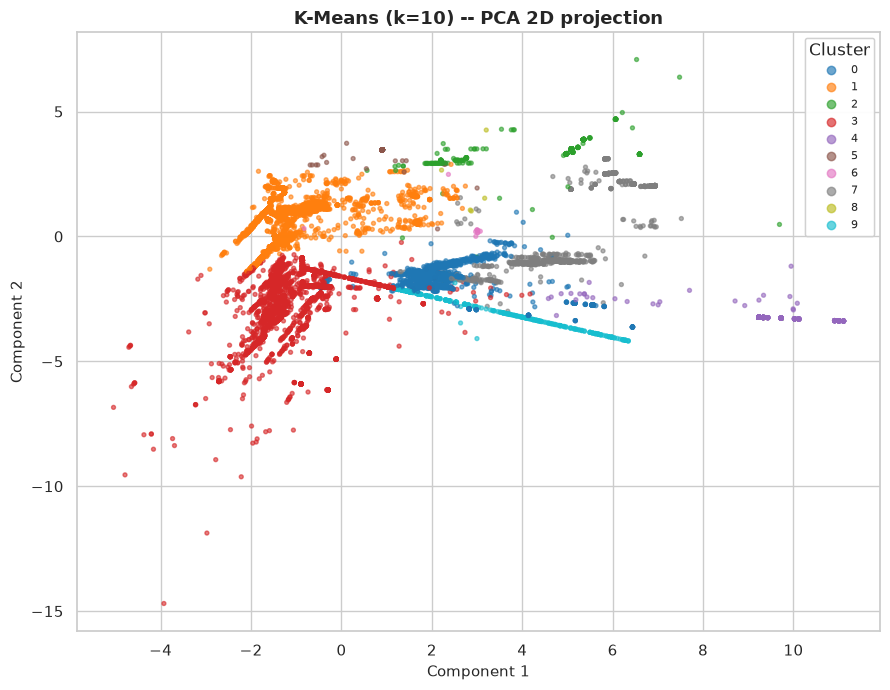

In [15]:
# One 2D PCA, fit on the larger sample and reused on the smaller one -- same
# consistency reasoning as the scaler and the variance-based PCA above.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_kmeans_2d = pca_2d.fit_transform(X_kmeans_scaled)
X_hier_2d = pca_2d.transform(X_hier_scaled)

utils.plot_2d_clusters(X_kmeans_2d, kmeans_labels, f"K-Means (k={OPTIMAL_K}) -- PCA 2D projection",
                        save_path=os.path.join(FIGURES_DIR, "kmeans_pca_2d.png"))


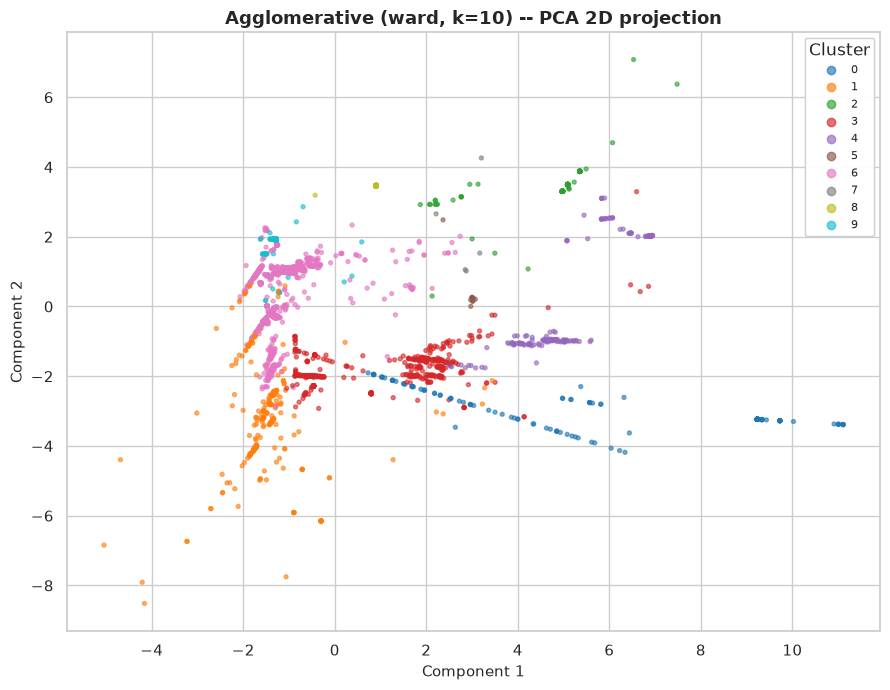

In [16]:
utils.plot_2d_clusters(X_hier_2d, agglomerative_labels,
                        f"Agglomerative ({best_linkage}, k={OPTIMAL_K}) -- PCA 2D projection",
                        save_path=os.path.join(FIGURES_DIR, "agglomerative_pca_2d.png"))


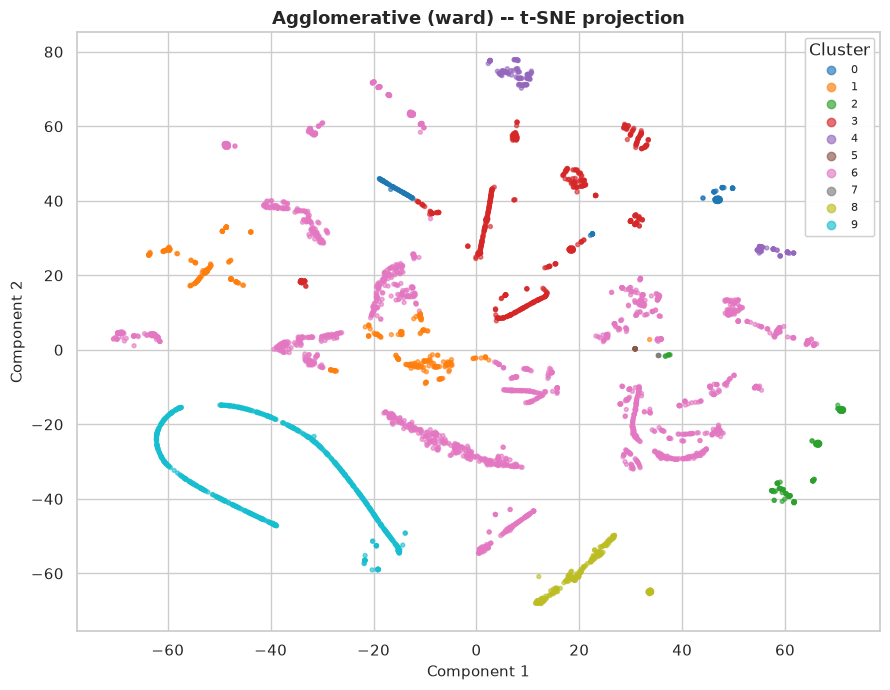

In [17]:
# t-SNE on the smaller hierarchical sample -- also too expensive to run on
# the full K-Means sample by default.
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
X_hier_tsne = tsne.fit_transform(X_hier_reduced)

utils.plot_2d_clusters(X_hier_tsne, agglomerative_labels,
                        f"Agglomerative ({best_linkage}) -- t-SNE projection",
                        save_path=os.path.join(FIGURES_DIR, "agglomerative_tsne.png"))


## 9. Interpreting the clusters (labels used only now, for interpretation)

This is the only place true labels appear in this notebook -- purely to
describe what each cluster turned out to represent, never to influence
how the clusters were formed.

In [18]:
cluster_profile = pd.crosstab(kmeans_labels, true_labels_kmeans, normalize="index").round(3) * 100
cluster_profile.index.name = "cluster"
cluster_profile


label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack ï¿½ Brute Force,Web Attack ï¿½ Sql Injection,Web Attack ï¿½ XSS
cluster,,,,,,,,,,,,,,,
0,1.2,0.0,22.4,4.4,67.7,0.0,3.7,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
1,4.9,8.1,7.8,12.6,1.4,0.7,6.4,11.6,0.0,0.0,17.1,16.2,9.0,0.1,4.1
2,0.4,0.0,0.0,0.9,0.1,11.3,86.8,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0
3,30.2,11.9,16.7,4.8,4.1,8.7,2.4,14.8,0.0,0.1,0.9,3.2,1.7,0.1,0.4
4,4.9,0.0,0.0,0.0,0.0,0.0,94.9,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0
5,0.3,0.0,0.0,0.1,0.0,98.8,0.6,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0
6,9.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.9,0.0,0.0,0.0,0.0,0.0,0.0
7,1.5,0.0,0.0,0.0,57.4,36.8,4.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0


In [19]:
dominant_label = cluster_profile.idxmax(axis=1)
dominant_pct = cluster_profile.max(axis=1)

summary = pd.DataFrame({
    "dominant_label": dominant_label,
    "dominant_pct": dominant_pct,
    "cluster_size": pd.Series(kmeans_labels).value_counts().sort_index(),
})
print("What each K-Means cluster mostly represents:")
summary


What each K-Means cluster mostly represents:


,dominant_label,dominant_pct,cluster_size
0,DoS Hulk,67.7,2067
1,PortScan,17.1,15240
2,DoS slowloris,86.8,1037
3,BENIGN,30.2,6073
4,DoS slowloris,94.9,526
5,DoS Slowhttptest,98.8,1421
6,Heartbleed,90.9,11
7,DoS Hulk,57.4,1395
8,Infiltration,100.0,5
9,DoS GoldenEye,98.9,357


## 10. Save clustering artifacts

In [20]:
joblib.dump(kmeans_final, os.path.join(MODELS_DIR, "kmeans_model.joblib"))
joblib.dump(scaler_clustering, os.path.join(MODELS_DIR, "scaler.joblib"))
joblib.dump(pca_model, os.path.join(MODELS_DIR, "pca_transformer.joblib"))

summary.to_csv(os.path.join(MODELS_DIR, "cluster_profile.csv"))
with open(os.path.join(MODELS_DIR, "dropped_correlated_features.json"), "w") as f:
    import json
    json.dump(to_drop, f, indent=2)

print(f"Saved K-Means model, scaler, PCA transformer, and cluster profile to {MODELS_DIR}")


Saved K-Means model, scaler, PCA transformer, and cluster profile to ../models/clustering


## 11. Possible mistakes to watch for

- **Letting labels influence k selection.** The elbow/silhouette analysis
  above only looks at the unlabeled feature space -- `true_labels_kmeans`
  is never referenced until section 9. Keep it that way if you extend this.
- **Comparing K-Means and Agglomerative metrics directly.** They ran on
  different sample sizes (40,000 vs 5,000 rows) for the memory reasons
  explained in section 2 -- their silhouette/DB/CH scores are each
  meaningful on their own but not perfectly comparable to each other.
- **Expecting clusters to equal attack types 1:1.** A cluster might span
  multiple attack categories that share similar traffic *behavior* (e.g.
  several flooding-style attacks), or a single attack type might split
  across clusters if it has sub-behaviors. Report what you actually find
  in section 9 rather than the count of classes from the classification
  notebook.
- **Silhouette score on the full K-Means sample.** `sample_size=5000` is
  used above purely to keep the metric computation itself fast (it also
  has quadratic cost) -- this is a sampling of the *metric calculation*,
  not of the clustering itself, which still used the full 40,000 rows.


## 12. Final summary & conclusion

**What was done.** Two unsupervised algorithms -- K-Means and
Agglomerative clustering -- were fit on the cleaned, feature-engineered
dataset with labels withheld throughout training. 33 highly-correlated
features (|r| > 0.9) were dropped before scaling (train-fit
`StandardScaler`) and PCA reduction to 22 components (95% variance
retained), since correlated features double-count in the Euclidean
distances both algorithms rely on.

**Preprocessing decisions.** K-Means used a 28,132-row stratified sample;
Agglomerative and t-SNE used a smaller 4,064-row subset of it (a full
pairwise distance matrix on 28k rows would be memory-prohibitive) --
the same fitted scaler and PCA transform are reused across both samples
rather than refitting separately, so they stay on a consistent scale.

**Model comparison / selection findings.** K-Means: k=10 selected by
silhouette score. Agglomerative: "average" linkage scored *higher* on
raw silhouette (0.69) than "ward" (0.45), but was correctly rejected by
the balance safeguard -- it crammed 99.1% of points into one cluster,
a degenerate, useless split; "ward" (46.2% largest cluster) was chosen
instead as the genuinely useful segmentation. This is a concrete
demonstration of why silhouette alone can mislead for hierarchical
clustering.

**Cluster interpretation (labels used only after fitting).** Several
K-Means clusters are highly pure with respect to real attack labels
despite never seeing them during training: cluster 9 is 98.9% DoS
GoldenEye, cluster 5 is 98.8% DoS Slowhttptest, cluster 6 is 90.9%
Heartbleed, cluster 8 is 100% Infiltration (though only 5 points).
Cluster 1, the largest (15,240 points), is a mixed bag dominated by
PortScan at only 17.1% -- showing that behaviorally similar traffic
(BENIGN, PortScan, and several low-rate attacks) genuinely overlaps in
feature space rather than separating cleanly, an honest finding rather
than a forced 1:1 cluster-to-label mapping.

**Metrics.** K-Means silhouette = 0.426, Davies-Bouldin = 0.899; Agglomerative
(ward) silhouette = 0.453, Davies-Bouldin = 1.021 -- each meaningful on
its own, but not directly comparable to each other since the two
algorithms ran on different sample sizes.

**Limitations.** K-Means and Agglomerative results aren't directly
comparable (different sample sizes); silhouette on the full K-Means
sample is itself computed on a 5,000-point sub-sample for speed; cluster
count (10) doesn't need to, and doesn't, match the 15 real attack
categories, since clustering groups by behavioral similarity, not label
identity.

**Future improvements.** Try density-based clustering (DBSCAN/HDBSCAN)
which doesn't assume convex clusters and could better isolate the
mixed-behavior traffic found in cluster 1; use `MiniBatchKMeans` to scale
K-Means to the full 2.52M-row dataset instead of a working sample.
